$\Large Z1 = e^{-X^2 - Y^2}$

$\Large Z2 = e^{-(X - 1)^2 - (Y - 1)^2}$

$\Large Z = Z1 - Z2$

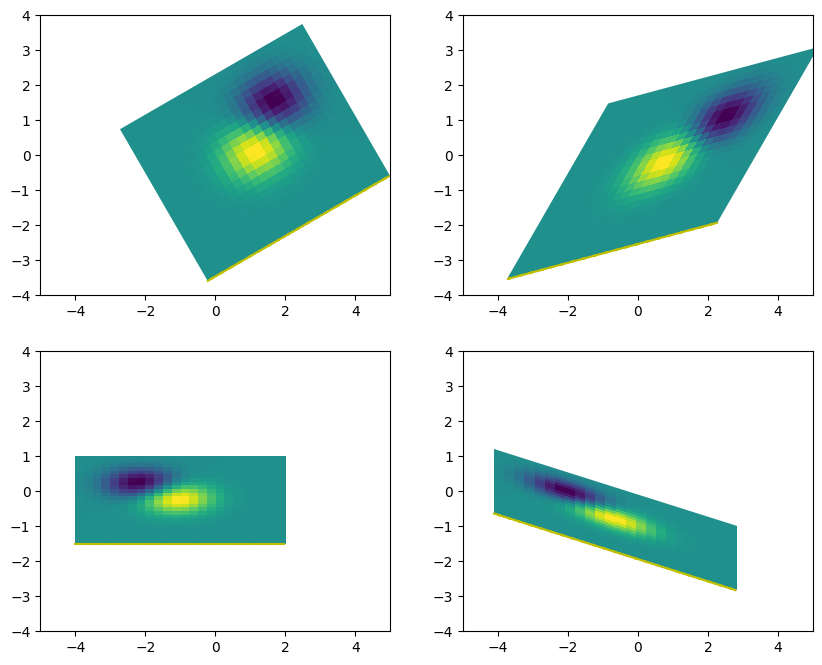

In [13]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import matplotlib.transforms as mtransforms


def get_image():
    delta = 0.25
    x = y = np.arange(-3.0, 3.0, delta)
    X, Y = np.meshgrid(x, y)
    Z1 = np.exp(-(X**2) - Y**2)
    Z2 = np.exp(-((X - 1) ** 2) - (Y - 1) ** 2)
    Z = Z1 - Z2

    return Z


def do_plot(ax: matplotlib.axes._axes.Axes, Z, transform):
    im = ax.imshow(Z, interpolation="none", origin="lower", extent=[-2, 4, -3, 2], clip_on=True)
    trans_data = transform + ax.transData
    im.set_transform(trans_data)

    # display intended extent of the image
    x1, x2, y1, y2 = im.get_extent()
    ax.plot([x1, x2, x2, x1, x1], [y1, y1, y1, y1, y1], "y--", transform=trans_data)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-4, 4)


# Prepare image and figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))
Z = get_image()

# image rotation
do_plot(ax1, Z, mtransforms.Affine2D().rotate_deg(30))

# image skew
do_plot(ax2, Z, mtransforms.Affine2D().skew_deg(30, 15))

# scale and reflection
do_plot(ax3, Z, mtransforms.Affine2D().scale(-1, 0.5))

# everything and a translation
# fmt: off
do_plot(ax4, Z, mtransforms.Affine2D()
                            .rotate_deg(30)
                            .skew_deg(30, 15)
                            .scale(-1, 0.5)
                            .translate(0.5, -1))